# Notebook 12: Final Biomarker Validation and Integration

## Objective

To integrate the findings from machine learning, consensus biomarker selection, hub gene analysis, survival analysis, and SHAP explainability to identify the final validated biomarkers for Triple-Negative Breast Cancer.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
consensus = pd.read_csv("Consensus_Biomarkers.csv", index_col=0)

hub = pd.read_csv("Hub_Genes.csv")

shap = pd.read_csv("SHAP_Feature_Importance.csv")

survival = pd.read_csv("Survival_Analysis_Results.csv")

In [ ]:
survival.head()

,Gene,Hazard Ratio,95% CI,Log-rank p-value,Interpretation
0,ESR1,0.64,0.58–0.71,<1E-16,Better survival
1,FOXA1,NaN,NaN,NaN,NaN
2,GATA3,NaN,NaN,NaN,NaN
3,ERBB2,NaN,NaN,NaN,NaN
4,AGR2,NaN,NaN,NaN,NaN


In [ ]:
survival["Log-rank p-value"] = (
    survival["Log-rank p-value"]
    .astype(str)
    .str.replace("<", "", regex=False)
)

survival["Log-rank p-value"] = pd.to_numeric(
    survival["Log-rank p-value"],
    errors="coerce"
)

In [ ]:
survival_genes = set(
    survival[
        survival["Log-rank p-value"] < 0.05
    ]["Gene"]
)

In [ ]:
consensus = pd.read_csv("Consensus_Biomarkers.csv", index_col=0)

hub = pd.read_csv("Hub_Genes.csv")

shap = pd.read_csv("SHAP_Feature_Importance.csv")

survival = pd.read_csv("Survival_Analysis_Results.csv")

In [ ]:
# Convert p-values to numeric
survival["Log-rank p-value"] = (
    survival["Log-rank p-value"]
    .astype(str)
    .str.replace("<", "", regex=False)
    .str.strip()
)

survival["Log-rank p-value"] = pd.to_numeric(
    survival["Log-rank p-value"],
    errors="coerce"
)

print(survival["Log-rank p-value"])

0    1.000000e-16
1             NaN
2             NaN
3             NaN
4             NaN
5             NaN
6             NaN
7             NaN
8             NaN
9             NaN
Name: Log-rank p-value, dtype: float64


In [ ]:
print(survival.dtypes)
print(survival.head())

Gene                 object
Hazard Ratio        float64
95% CI               object
Log-rank p-value    float64
Interpretation       object
dtype: object
    Gene  Hazard Ratio     95% CI  Log-rank p-value   Interpretation
0   ESR1          0.64  0.58–0.71      1.000000e-16  Better survival
1  FOXA1           NaN        NaN               NaN              NaN
2  GATA3           NaN        NaN               NaN              NaN
3  ERBB2           NaN        NaN               NaN              NaN
4   AGR2           NaN        NaN               NaN              NaN


In [ ]:
survival_genes = set(
    survival.loc[
        survival["Log-rank p-value"] < 0.05,
        "Gene"
    ]
)

In [ ]:
# Convert p-values to numeric
survival["Log-rank p-value"] = (
    survival["Log-rank p-value"]
    .astype(str)
    .str.replace("<", "", regex=False)
)

survival["Log-rank p-value"] = pd.to_numeric(
    survival["Log-rank p-value"],
    errors="coerce"
)

# Keep only significant genes
survival_genes = set(
    survival.loc[
        survival["Log-rank p-value"] < 0.05,
        "Gene"
    ]
)

print(survival_genes)

{'ESR1'}


In [ ]:
consensus_genes = set(consensus.index)

hub_genes = set(hub.head(20)["Gene"])

shap_genes = set(shap.head(20)["Gene"])

survival_genes = set(
    survival[
        survival["Log-rank p-value"] < 0.05
    ]["Gene"]
)

In [ ]:
all_genes = sorted(
    consensus_genes |
    hub_genes |
    shap_genes |
    survival_genes
)

In [ ]:
final = pd.DataFrame({

    "Gene": all_genes

})

final["Consensus Biomarker"] = final["Gene"].isin(consensus_genes)

final["Hub Gene"] = final["Gene"].isin(hub_genes)

final["Top SHAP Gene"] = final["Gene"].isin(shap_genes)

final["Survival Significant"] = final["Gene"].isin(survival_genes)

In [ ]:
final["Validation Score"] = (

    final["Consensus Biomarker"].astype(int)

    +

    final["Hub Gene"].astype(int)

    +

    final["Top SHAP Gene"].astype(int)

    +

    final["Survival Significant"].astype(int)

)

final = final.sort_values(

    by="Validation Score",

    ascending=False

)

final.head(20)

,Gene,Consensus Biomarker,Hub Gene,Top SHAP Gene,Survival Significant,Validation Score
27,ESR1,True,True,True,True,4
67,XBP1,True,True,True,False,3
35,GATA3,True,True,True,False,3
24,DNALI1,True,True,True,False,3
15,CA12,True,True,True,False,3
31,FOXA1,True,True,True,False,3
57,SPDEF,True,True,True,False,3
42,INPP4B,True,True,False,False,2
52,RND1,True,True,False,False,2
48,PPP1R14C,True,False,True,False,2


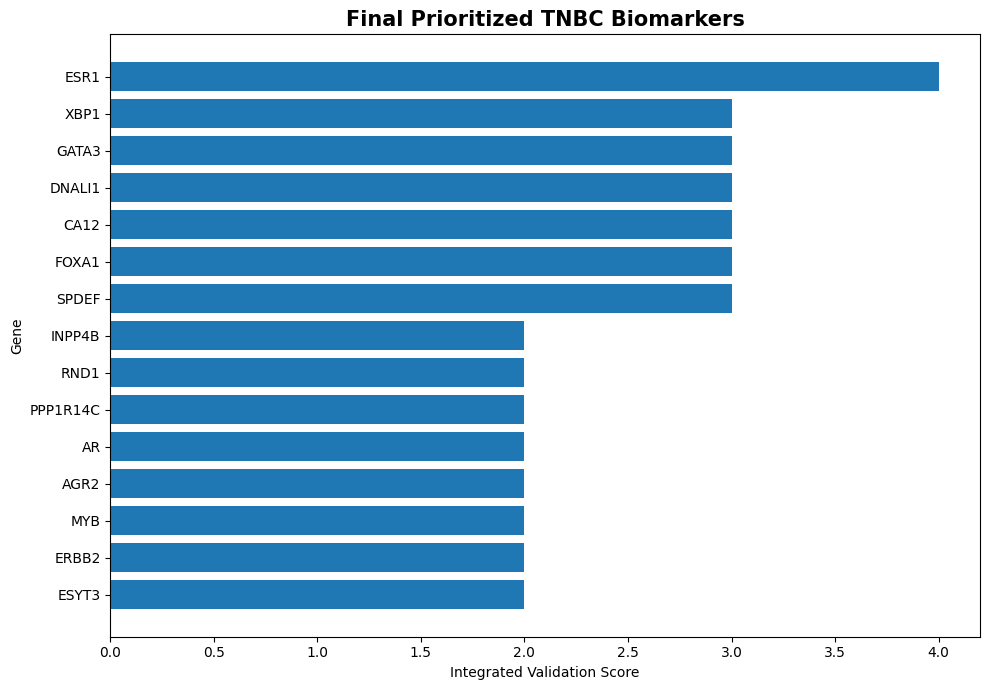

In [ ]:
top = final.head(15)

plt.figure(figsize=(10,7))

plt.barh(

    top["Gene"],

    top["Validation Score"]

)

plt.gca().invert_yaxis()

plt.xlabel("Integrated Validation Score")

plt.ylabel("Gene")

plt.title(

    "Final Prioritized TNBC Biomarkers",

    fontsize=15,

    fontweight="bold"

)

plt.tight_layout()

plt.savefig(

    "Figure18_Final_Biomarker_Ranking.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()

In [ ]:
final.to_csv(

    "Final_Validated_Biomarkers.csv",

    index=False

)

print("Notebook 12 completed successfully!")

Notebook 12 completed successfully!


In [ ]:
print("="*50)

print("FINAL PROJECT SUMMARY")

print("="*50)

print()

print("Consensus biomarkers :", len(consensus_genes))

print("Hub genes :", len(hub_genes))

print("Top SHAP genes :", len(shap_genes))

print("Survival validated :", len(survival_genes))

print()

print("Final biomarkers identified:")

print(final.head(10))

FINAL PROJECT SUMMARY

Consensus biomarkers : 64
Hub genes : 20
Top SHAP genes : 20
Survival validated : 1

Final biomarkers identified:
        Gene  Consensus Biomarker  Hub Gene  Top SHAP Gene  \
27      ESR1                 True      True           True   
67      XBP1                 True      True           True   
35     GATA3                 True      True           True   
24    DNALI1                 True      True           True   
15      CA12                 True      True           True   
31     FOXA1                 True      True           True   
57     SPDEF                 True      True           True   
42    INPP4B                 True      True          False   
52      RND1                 True      True          False   
48  PPP1R14C                 True     False           True   

    Survival Significant  Validation Score  
27                  True                 4  
67                 False                 3  
35                 False                 3  


In [ ]:
import os

for file in sorted(os.listdir()):
    print(file)

.config
Consensus_Biomarkers.csv
Figure18_Final_Biomarker_Ranking.png
Final_Validated_Biomarkers.csv
Hub_Genes.csv
SHAP_Feature_Importance.csv
Survival_Analysis_Results.csv
Top10_Hub_Genes.csv
sample_data


In [ ]:
import pandas as pd

final = pd.read_csv("Final_Validated_Biomarkers.csv")

print("="*60)
print("TNBC PROJECT COMPLETED")
print("="*60)

print()

print("Total final biomarkers:", len(final))

print()

print("Top 15 validated biomarkers")

display(final.head(15))

TNBC PROJECT COMPLETED

Total final biomarkers: 70

Top 15 validated biomarkers


,Gene,Consensus Biomarker,Hub Gene,Top SHAP Gene,Survival Significant,Validation Score
0,ESR1,True,True,True,True,4
1,XBP1,True,True,True,False,3
2,GATA3,True,True,True,False,3
3,DNALI1,True,True,True,False,3
4,CA12,True,True,True,False,3
5,FOXA1,True,True,True,False,3
6,SPDEF,True,True,True,False,3
7,INPP4B,True,True,False,False,2
8,RND1,True,True,False,False,2
9,PPP1R14C,True,False,True,False,2


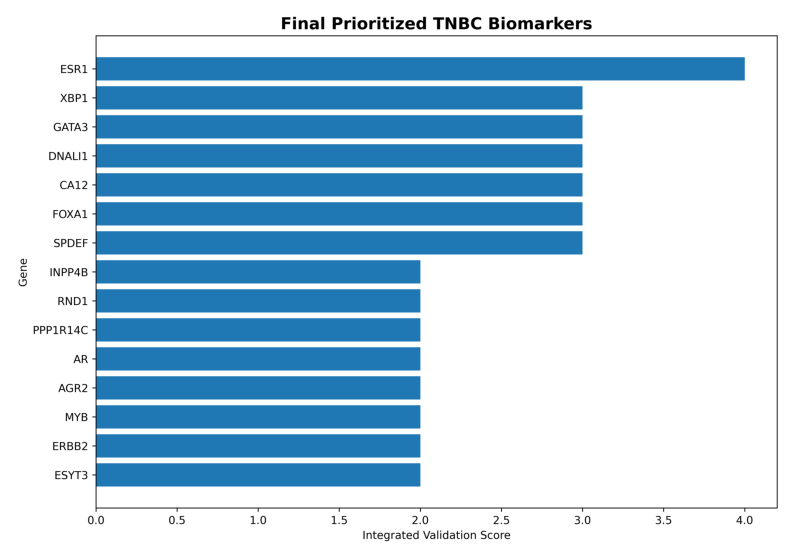

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Figure18_Final_Biomarker_Ranking.png")

plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis("off")
plt.show()